In [60]:
"""
================================================================================
TITLE         : NLP Assignment 1 | 
GROUP NUMBER  : 
GROUP MEMBERS :
S.No.   BITS_ID           NAME--------------------------------------------------
1.      2024ac05382       HAREESH KUMAR K
2.      2024ac05361       RAHUL CHANDRAN
3.                        JAPNEET SINGH
-------------------------------------------------------------
ASSIGNMENT OVERVIEW: 
================================================================================
"""

'\n================================================================================\nTITLE         : NLP Assignment 1 | \nGROUP NUMBER  : \nGROUP MEMBERS :\nS.No.   BITS_ID           NAME--------------------------------------------------\n1.      2024ac05382       HAREESH KUMAR K\n2.      2024ac05361       RAHUL CHANDRAN\n3.                        JAPNEET SINGH\n-------------------------------------------------------------\nASSIGNMENT OVERVIEW: \n================================================================================\n'

## Cell 1 - Download and perform EDA on NLTK Brown Dataset

In [61]:
# Configure Necessary Imports in accordance to the requirements of the assignment
import nltk
from collections import Counter
import pandas as pd


In [62]:
# Download the brown corpus if not already downloaded
nltk.download('brown')
# Verify the import and availability of the brown corpus
from nltk.corpus import brown
print("Brown Corpus Categories:", brown.categories())
# Load the tagged sentences from the brown corpus for training and testing
train_data = brown.tagged_sents(categories="government")
test_data = brown.tagged_sents(categories="humor")
# Extract some metrics from the training data
sent_train_data_count = len(train_data)
token_train_data_count = sum(len(sent) for sent in train_data)
print("Number of training sentences:", sent_train_data_count)
print("Number of training tokens:", token_train_data_count)
print("First training sentence:", train_data[0])
print("Token count ", token_train_data_count)

# Extract the tag counts and vocabulary from the training data followed by 
# a data preprocessing step.
tag_counts = Counter()
word_counts = Counter()
vocab = set()
clean_train_data = []
for sent in train_data:
    cleaned_sent = []
    for word, tag in sent:
        cleaned_sent.append((word.lower(), tag))
    clean_train_data.append(cleaned_sent)

for sent in clean_train_data:
    for word, tag in sent:
        tag_counts[tag] += 1
        word_counts[word.lower()] += 1
        vocab.add(word.lower())

print("Tag counts:", tag_counts)
print("Word frequencies:", word_counts)
print("Vocabulary size:", len(vocab))
print("Vocabulary:", sorted(vocab))



[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\rahul\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!


Brown Corpus Categories: ['adventure', 'belles_lettres', 'editorial', 'fiction', 'government', 'hobbies', 'humor', 'learned', 'lore', 'mystery', 'news', 'religion', 'reviews', 'romance', 'science_fiction']
Number of training sentences: 3032
Number of training tokens: 70117
First training sentence: [('The', 'AT'), ('Office', 'NN-TL'), ('of', 'IN-TL'), ('Business', 'NN-TL'), ('Economics', 'NN-TL'), ('(', '('), ('OBE', 'NP'), (')', ')'), ('of', 'IN'), ('the', 'AT'), ('U.S.', 'NP-TL'), ('Department', 'NN-TL'), ('of', 'IN-TL'), ('Commerce', 'NN-TL'), ('provides', 'VBZ'), ('basic', 'JJ'), ('measures', 'NNS'), ('of', 'IN'), ('the', 'AT'), ('national', 'JJ'), ('economy', 'NN'), ('and', 'CC'), ('current', 'JJ'), ('analysis', 'NN'), ('of', 'IN'), ('short-run', 'NN'), ('changes', 'NNS'), ('in', 'IN'), ('the', 'AT'), ('economic', 'JJ'), ('situation', 'NN'), ('and', 'CC'), ('business', 'NN'), ('outlook', 'NN'), ('.', '.')]
Token count  70117
Tag counts: Counter({'NN': 9877, 'IN': 8596, 'AT': 5716, 

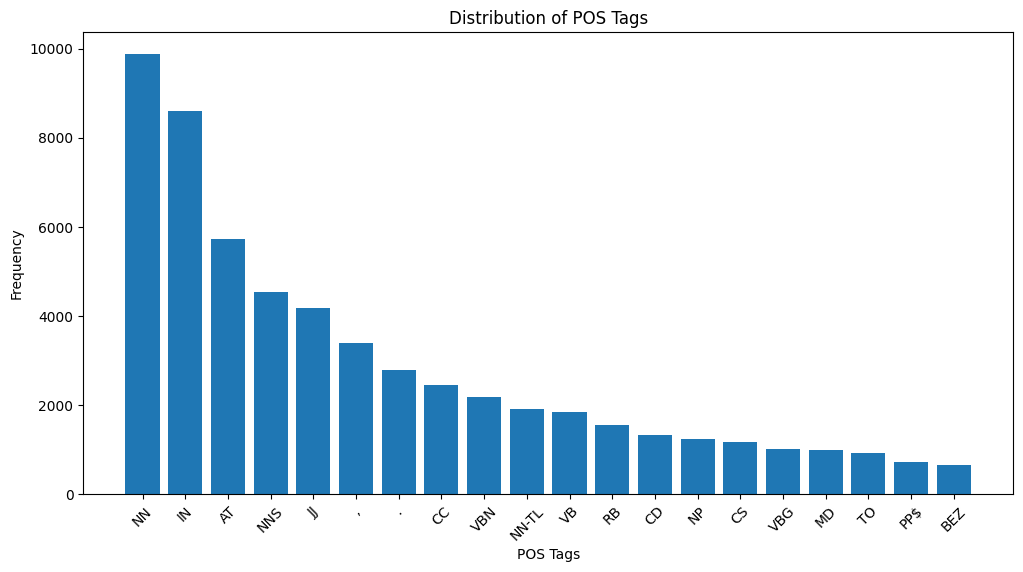

In [63]:
#plot POS tag distribution of the top 20 most common tags
top_tags = tag_counts.most_common(20)
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.bar([tag for tag, freq in top_tags], [freq for tag, freq in top_tags])
plt.xlabel("POS Tags")
plt.ylabel("Frequency")
plt.title("Distribution of POS Tags")
plt.xticks(rotation=45)
plt.show()

In [64]:
# Get Frequency of words less than or equal to 2
low_freq_words = {word: freq for word, freq in word_counts.items() if freq <= 2}
print("Words with frequency <= 2:", low_freq_words)
# replace low frequency words in the training data with <UNK>
train_data_unk = []

for sent in clean_train_data:
    new_sent = [(word if word.lower() not in low_freq_words else "<UNK>", tag) for word, tag in sent]
    train_data_unk.append(new_sent)
# Pad the sentences in the training data with <START> and <END> tokens
train_data_padded = []
for sent in train_data_unk:
    new_sent = [("<START>", "<START>")] + sent + [("<END>", "<END>")]
    train_data_padded.append(new_sent)
print("Sample padded sentence:", train_data_padded[0])
print("Length of padded training data:", len(train_data_padded[0]))


Words with frequency <= 2: {'obe': 1, 'short-run': 2, 'develops': 1, 'analyzes': 1, 'indicators': 1, 'presenting': 2, 'economists': 2, 'periodical': 2, 'statistical': 2, 'supplements': 1, 'dealt': 2, 'managers': 1, 'enterprises': 2, 'know-how': 1, 'cosponsors': 1, "sba's": 2, 'personalized': 1, 'one-day': 1, 'streamlined': 1, 'chambers': 2, 'semi-processed': 1, 'adaptable': 1, 'exploitation': 1, 'arise': 2, 'undertook': 1, 'urgently': 2, 'locate': 2, 'competitively': 1, 'reviewing': 1, 'identifying': 2, 'publicized': 1, 'releases': 1, 'flyers': 1, 'principally': 2, 'contacted': 1, '8-b-2': 1, 'authorizes': 1, 'voluntarily': 1, 'register': 1, 'avail': 1, "registrants'": 1, 'budgetary': 2, 'atlanta': 2, 'ga.': 2, 'mass.': 2, 'dallas': 2, 'tex.': 2, 'denver': 2, 'colo.': 2, 'detroit': 2, 'mich.': 2, 'mo.': 2, 'minneapolis': 2, 'minn.': 2, 'n.y.': 2, 'pa.': 2, 'va.': 2, 'san': 2, 'francisco': 2, 'seattle': 2, 'wash.': 2, 'topics': 2, 'selling': 1, 'lending': 2, 'pools': 1, 'wholesalers': 1

## Cell 7 - Model Architecture & Parameter Estimation

In [65]:
# Loop through the training data set and extract the 
#   1. Tag -> Tag transition counts
#   2. Word -> Tag emission counts

unk_prob = 1e-6
transition_counts = Counter()
emission_counts = Counter()
for sent in train_data_padded:
    for i in range(1, len(sent)):
        prev_tag = sent[i-1][1]
        curr_tag = sent[i][1]
        transition_counts[(prev_tag, curr_tag)] += 1
        emission_counts[(sent[i][0].lower(), curr_tag)] += 1
#Update tag_counts to include the <START> and <END> tags
tag_counts["<START>"] = len(train_data_padded)
tag_counts["<END>"] = len(train_data_padded)

print("Tag Transition Counts:", transition_counts)
print("Word-Tag Emission Counts:", emission_counts)

Tag Transition Counts: Counter({('NN', 'IN'): 3150, ('IN', 'AT'): 2887, ('AT', 'NN'): 2560, ('.', '<END>'): 2531, ('JJ', 'NN'): 1883, ('NNS', 'IN'): 1430, ('IN', 'NN'): 1430, ('NN', 'NN'): 1055, ('AT', 'JJ'): 1010, ('NN', ','): 997, ('JJ', 'NNS'): 991, ('NN', '.'): 938, ('VBN', 'IN'): 896, ('TO', 'VB'): 783, ('IN', 'JJ'): 775, ('NN', 'NNS'): 683, ('NN', 'CC'): 624, (',', 'CC'): 575, ('NNS', ','): 568, ('<START>', 'AT'): 558, ('NNS', '.'): 548, ('AT', 'NN-TL'): 521, ('IN', 'NNS'): 484, ('CC', 'NN'): 437, ('MD', 'BE'): 403, ('AT', 'NNS'): 401, ('VB', 'AT'): 397, ('IN', 'CD'): 384, ('BE', 'VBN'): 376, ('MD', 'VB'): 365, ('<START>', 'IN'): 364, ('NNS', 'CC'): 362, ('IN', 'PP$'): 349, (',', 'IN'): 342, ('IN', 'VBG'): 334, (',', 'AT'): 331, ('IN', 'DT'): 328, ('DT', 'NN'): 325, ('CS', 'AT'): 318, ('NN-TL', 'IN-TL'): 301, ('PP$', 'NN'): 292, ('IN', 'NP'): 288, ('NN-TL', 'NN-TL'): 286, ('JJ', 'IN'): 283, ('RB', 'IN'): 282, ('NN-TL', ','): 275, ('CD', 'NNS'): 266, ('VB', 'IN'): 261, ('NN', 'MD'

In [66]:
#Do a sanity check to check if the transition counts exceed the previous tag counts
# DEBUG CODE . PLEASE DO NOT USE THIS IF NOT REQUIRD
# for (prev_tag, curr_tag), count in transition_counts.items():
#     if count > tag_counts[prev_tag]:
#         print(f"Sanity Check Failed: Transition count from {prev_tag} to {curr_tag} exceeds total count of {prev_tag}")
#     else:
#         print(f"Sanity Check Passed: Transition count from {prev_tag} to {curr_tag} is within expected limits.")

In [67]:
# Convert the transition and emission counts to probabilities (MLE)
# OOV FIX: <UNK> is treated as a normal word and gets a proper per-tag MLE
# emission distribution, learned from the low-frequency words that were
# mapped to <UNK> during counting. This gives unknown words a meaningful
# tag distribution (e.g. unknowns are far more likely to be nouns) instead
# of a flat constant that carries no signal for the Viterbi decoder.
from collections import defaultdict

# Transition probabilities: P(curr | prev) = C(prev, curr) / C(prev)
trans_totals = defaultdict(int)
for (prev_tag, curr_tag), count in transition_counts.items():
    trans_totals[prev_tag] += count

transition_probs = {}
for (prev_tag, curr_tag), count in transition_counts.items():
    transition_probs[(prev_tag, curr_tag)] = count / trans_totals[prev_tag]

# Emission probabilities: P(word | tag) = C(word, tag) / C(tag)
# <UNK> is included here naturally because low-freq words were already
# replaced by <UNK> before counting.
emis_totals = defaultdict(int)
for (word, tag), count in emission_counts.items():
    emis_totals[tag] += count

emission_probs = {}
for (word, tag), count in emission_counts.items():
    emission_probs[(word, tag)] = count / emis_totals[tag]

print("Tag Transition Probabilities (sample):",
      dict(list(transition_probs.items())[:5]))
print("Word-Tag Emission Probabilities (sample):",
      dict(list(emission_probs.items())[:5]))
print("\n<UNK> emission distribution across tags (top 8):")
unk_dist = sorted(((t, p) for (w, t), p in emission_probs.items() if w == "<UNK>"),
                  key=lambda x: -x[1])[:8]
for t, p in unk_dist:
    print(f"  P(<UNK> | {t}) = {p:.4f}")


Tag Transition Probabilities (sample): {('<START>', 'AT'): 0.18403693931398418, ('AT', 'NN-TL'): 0.09114765570328902, ('NN-TL', 'IN-TL'): 0.15701617110067814, ('IN-TL', 'NN-TL'): 0.27019498607242337, ('NN-TL', 'NN-TL'): 0.14919144496609285}
Word-Tag Emission Probabilities (sample): {('the', 'AT'): 0.7844646606018194, ('office', 'NN-TL'): 0.009389671361502348, ('of', 'IN-TL'): 0.8913649025069638, ('business', 'NN-TL'): 0.008868022952529996, ('economics', 'NN-TL'): 0.0010432968179447052}

<UNK> emission distribution across tags (top 8):


In [68]:

transition_df = pd.DataFrame([(k[0], k[1], count) for k, count in transition_counts.items()],\
                             columns=["Prev Tag", "Curr Tag", "Count"])
top20_transitions = transition_df.nlargest(20, "Count")
emission_df = pd.DataFrame([(k[0], k[1], count) for k, count in emission_counts.items()],\
                             columns=["Word", "Tag", "Count"])
top20_emissions = emission_df.nlargest(20, "Count")

In [69]:
# Code to analyze the tags associated with the words "(" and ")" in the training data
# USE ONLY FOR DEBUGGING PURPOSES. DO NOT USE THIS CODE IN THE FINAL SUBMISSION AS IT IS 
# NOT PART OF THE ASSIGNMENT REQUIREMENTS.
# words_for_tag = set()

# for (word, tag), count in emission_counts.items():
#     if tag == "()":
#         words_for_tag.add(word)

# print(words_for_tag)
# all_tags = set(tag for (_, tag) in emission_counts.keys())

# # for tag in sorted(all_tags):
# #     if "(" in str(tag) or ")" in str(tag):
# #         print(repr(tag))
# for (word, tag), count in emission_counts.items():
#     if tag == "(":
#         print(repr(word), count)

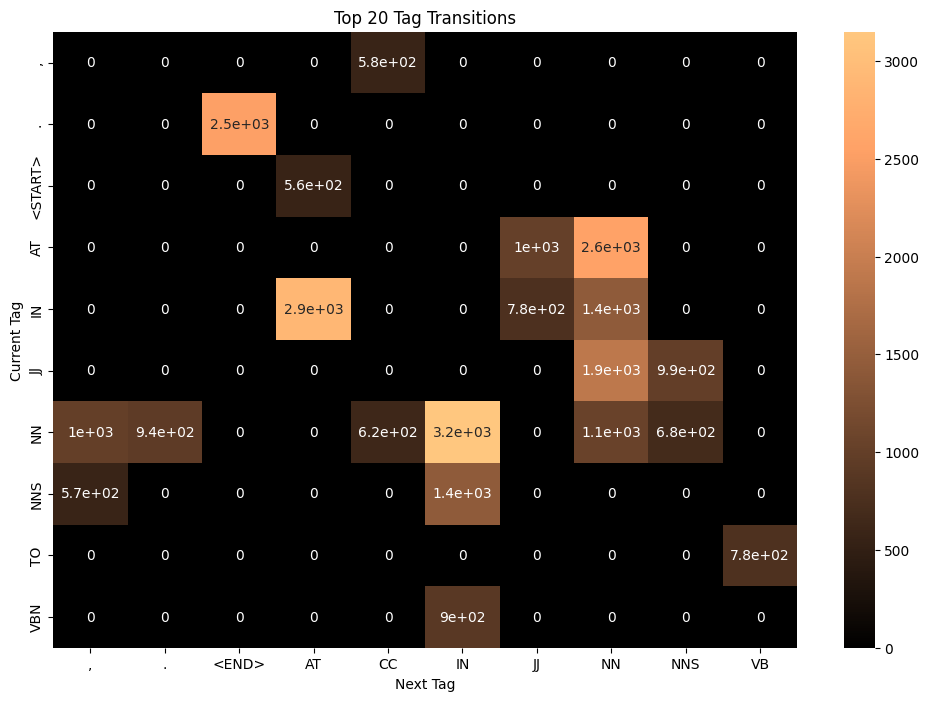

In [70]:
#Plot the transition counts of the top 20 most common tag transitions as a heatmap
import seaborn as sns
import matplotlib.pyplot as plt
heatmap_df_transitions = top20_transitions.pivot(index="Prev Tag", columns="Curr Tag", values="Count").fillna(0)
plt.figure(figsize=(12,8))
sns.heatmap(heatmap_df_transitions, annot=True, cmap="copper")
plt.title("Top 20 Tag Transitions")
plt.xlabel("Next Tag")
plt.ylabel("Current Tag")
plt.show()


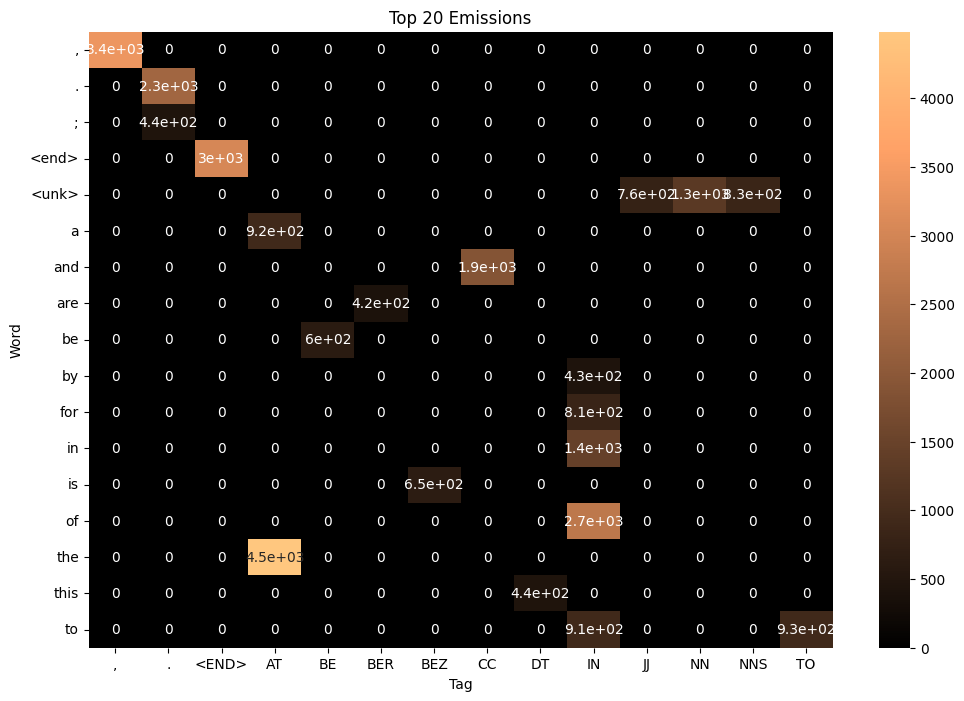

In [71]:
#Plot the emission counts of the top 20 most common tag transitions as a heatmap
import seaborn as sns
import matplotlib.pyplot as plt
heatmap_df_emissions = top20_emissions.pivot(index="Word", columns="Tag", values="Count").fillna(0)
plt.figure(figsize=(12,8))
sns.heatmap(heatmap_df_emissions, annot=True, cmap="copper")
plt.title("Top 20 Emissions")
plt.xlabel("Tag")
plt.ylabel("Word")
plt.show()

## Cell 15 - Preprocess Test Data Set to run the Viterbi Algorithm 

In [72]:
# PREPROCESS THE TEST DATA IN THE SAME WAY AS THE TRAINING DATA
# 1. Lowercase every word.
# 2. Map any word NOT in the training vocabulary to <UNK>.
#    (Note: we use the *training* vocabulary, not the train low_freq set,
#     because the model has only ever seen <UNK> emissions for words it did
#     not learn during training. Any genuinely unseen test word is OOV.)
# 3. Pad sentences with <START> and <END>.

# Build the set of words the model actually learned emissions for.
train_vocab = set(word for (word, tag) in emission_counts.keys())

def preprocess_word_for_inference(word):
    w = word.lower()
    return w if w in train_vocab else "<UNK>"

test_data_unk = []
for sent in test_data:
    new_sent = [(preprocess_word_for_inference(word), tag) for word, tag in sent]
    test_data_unk.append(new_sent)

test_data_padded = []
for sent in test_data_unk:
    new_sent = [("<START>", "<START>")] + sent + [("<END>", "<END>")]
    test_data_padded.append(new_sent)

print("Sample padded test sentence:", test_data_padded[0])
print("Number of test sentences:", len(test_data_padded))


Sample padded test sentence: [('<START>', '<START>'), ('it', 'PPS'), ('was', 'BEDZ'), ('among', 'IN'), ('these', 'DTS'), ('that', 'CS'), ('<UNK>', 'NP'), ('<UNK>', 'VBD'), ('a', 'AT'), ('<UNK>', 'NN'), ('of', 'IN'), ('<UNK>', 'NP'), ('<UNK>', '.'), ('<UNK>', '.'), ('<END>', '<END>')]
Number of test sentences: 1053


## Cell 17 - Apply the Viterbi Algorithm to predict the POS tags for the test data sentences 


In [ ]:
# ============================================================================
# VITERBI ALGORITHM (from scratch)
# ----------------------------------------------------------------------------
# Dynamic-programming decoder that returns the most likely sequence of POS
# tags for a sequence of words. We work in LOG space to avoid numerical
# underflow on long sentences (products of many small probabilities).
# ============================================================================
import math

# Hidden states = all real POS tags (exclude the structural <START>/<END>).
states = [t for t in tag_counts if t not in ("<START>", "<END>")]

#DEBUG PRINT CODE DELETE AFTER USE
#print ("States:", states[:10], "...")
#DEBUG END

LOG_ZERO = -1e18          # stand-in for log(0)
FLOOR    = 1e-12          # smoothing floor inside the log

def log(p):
    return math.log(p) if p > 0 else LOG_ZERO

def get_transition_prob(prev_tag, curr_tag):
    return transition_probs.get((prev_tag, curr_tag), FLOOR)

def get_emission_prob(word, tag):
    """OOV-aware emission lookup. Unknown words fall back to the learned
    <UNK> distribution rather than a flat constant."""
    w = word.lower()
    if (w, tag) in emission_probs:
        return emission_probs[(w, tag)]
    if ("<UNK>", tag) in emission_probs:
        return emission_probs[("<UNK>", tag)]
    return FLOOR

def viterbi_decode(words):
    """Input: list of raw words. Output: list of predicted POS tags."""
    # Map words into the model's vocabulary exactly as in training.
    obs = [w.lower() for w in words]
    obs = [w if w in train_vocab else "<UNK>" for w in obs]
    #DEBUG PRINT CODE DELETE AFTER USE
    print("Observations after preprocessing:", obs)
    #END DEBUG
    n = len(obs)
    if n == 0:
        return []

    viterbi    = [{} for _ in range(n)]
    backpointer = [{} for _ in range(n)]

    # Initialisation: transition from <START> into each tag * emission.
    for s in states:
        viterbi[0][s] = log(get_transition_prob("<START>", s)) + log(get_emission_prob(obs[0], s))
        backpointer[0][s] = None
        # #DEBUG PRINT CODE DELETE AFTER USE
        # print(f"Initial score for {s}: {viterbi[0][s]}")
        # #END DEBUG

    # Recursion.
    for i in range(1, n):
        for s in states:
            
            em = log(get_emission_prob(obs[i], s))
            # #DEBUG PRINT CODE DELETE AFTER USE
            # print(f"Emission score for {s} at position {i}: {em}")
            # #END DEBUG
            best_score, best_prev = LOG_ZERO, None
            for ps in states:       
                score = viterbi[i - 1][ps] + log(get_transition_prob(ps, s)) + em
                if score > best_score:
                    best_score, best_prev = score, ps
            viterbi[i][s] = best_score
            backpointer[i][s] = best_prev
            # #DEBUG PRINT CODE DELETE AFTER USE
            # print(f"Score for {s} at position {i}: {viterbi[i][s]}")
            # print(f"Backpointer best_prev for {s} at position {i}: {backpointer[i][s]}")
            # #END DEBUG

    # Termination: best final state, including transition into <END>.
    best_score, best_last = LOG_ZERO, None
    for s in states:
        score = viterbi[n - 1][s] + log(get_transition_prob(s, "<END>"))
        if score > best_score:
            best_score, best_last = score, s

    # Back-trace.
    best_path = [best_last]
   
    for i in range(n - 1, 0, -1):
        best_path.insert(0, backpointer[i][best_path[0]])
    # #DEBUG PRINT CODE DELETE AFTER USE
    # print(f"best_score: {best_score}")
    # print(f"best path: {best_path}")
    # #END DEBUG
    return best_path

# Quick smoke test on the first training sentence.
demo_words = [w for w, t in train_data[0]]
demo_pred  = viterbi_decode(demo_words)
print("Demo sentence:", demo_words[:10], "...")
print("Predicted tags:", demo_pred[:10], "...")


Observations after preprocessing: ['<UNK>', 'the', 'office', 'of', 'business', 'economics', '(', '<unk>', ')', 'of', 'the', 'u.s.', 'department', 'of', 'commerce', 'provides', 'basic', 'measures', 'of', 'the', 'national', 'economy', 'and', 'current', 'analysis', 'of', '<unk>', 'changes', 'in', 'the', 'economic', 'situation', 'and', 'business', 'outlook', '.', '<end>']
Demo sentence: ['<START>', 'the', 'office', 'of', 'business', 'economics', '(', '<UNK>', ')', 'of'] ...
Predicted tags: ['VB', 'AT', 'NN-TL', 'IN-TL', 'NN-TL', 'NN-TL', '(', 'NP', ')', 'IN'] ...


## Cell 19 - Inference and Evaluation

(a) Decode 4 test sentences (2 from the training category, 2 from the test category).
(b) Identify 3 sentences with at least one misclassified tag and analyse why.
(c) Overall token-level accuracy + confusion matrix for the top-5 POS tags.

In [74]:
# 3(a) Sequence Inference: decode 2 sentences from the training (government)
# category and 2 from the test (humor) category. We print word | gold | pred.

def show_prediction(sent, title):
    words = [w for w, t in sent]
    gold  = [t for w, t in sent]
    pred  = viterbi_decode(words)
    print("=" * 70)
    print(title)
    print("=" * 70)
    print(f"{'WORD':<18}{'GOLD':<10}{'PRED':<10}{'OK?'}")
    print("-" * 50)
    for w, g, p in zip(words, gold, pred):
        flag = "" if g == p else "  <-- MISMATCH"
        print(f"{w:<18}{g:<10}{p:<10}{flag}")
    acc = sum(g == p for g, p in zip(gold, pred)) / len(gold)
    print(f"Sentence accuracy: {acc:.2%}\n")

# 2 from training (government)
show_prediction(train_data[5],  "TRAIN SENTENCE #1 (government)")
show_prediction(train_data[12], "TRAIN SENTENCE #2 (government)")
# 2 from test (humor)
show_prediction(test_data[3],   "TEST SENTENCE #1 (humor)")
show_prediction(test_data[8],   "TEST SENTENCE #2 (humor)")


Observations after preprocessing: ['printed', 'material']
TRAIN SENTENCE #1 (government)
WORD              GOLD      PRED      OK?
--------------------------------------------------
Printed           VBN-HL    VBN-HL    
material          NN-HL     NN-HL     
Sentence accuracy: 100.00%

Observations after preprocessing: ['these', 'publications', ',', 'written', 'especially', 'for', 'the', '<UNK>', 'or', 'owners', 'of', 'small', 'businesses', ',', 'indirectly', 'aid', 'in', 'community', 'development', 'programs', '.']
TRAIN SENTENCE #2 (government)
WORD              GOLD      PRED      OK?
--------------------------------------------------
These             DTS       DTS       
publications      NNS       NNS       
,                 ,         ,         
written           VBN       VBN       
especially        RB        RB        
for               IN        IN        
the               AT        AT        
managers          NNS       NN          <-- MISMATCH
or                CC       

In [75]:
# 3(b) Find 3 distinct test (humor) sentences where Viterbi misclassified
# at least one tag, and print the specific errors for analysis.

found = 0
for idx, sent in enumerate(test_data):
    words = [w for w, t in sent]
    gold  = [t for w, t in sent]
    pred  = viterbi_decode(words)
    mism  = [(w, g, p) for w, g, p in zip(words, gold, pred) if g != p]
    # pick reasonably short sentences with a small number of clear errors
    if mism and 4 <= len(words) <= 14:
        print("=" * 70)
        print(f"Misclassified sentence #{found + 1} (test idx {idx})")
        print("Sentence:", " ".join(words))
        print("Errors (word | gold | predicted):")
        for w, g, p in mism:
            print(f"   {w:<15} {g:<8} -> {p}")
        print()
        found += 1
        if found == 3:
            break


Observations after preprocessing: ['it', 'was', 'among', 'these', 'that', '<UNK>', '<UNK>', 'a', '<UNK>', 'of', '<UNK>', '<UNK>', '<UNK>']
Misclassified sentence #1 (test idx 0)
Sentence: It was among these that Hinkle identified a photograph of Barco ! !
Errors (word | gold | predicted):
   that            CS       -> WPS
   Hinkle          NP       -> VBD
   identified      VBD      -> VBG
   Barco           NP       -> JJ
   !               .        -> NN

Observations after preprocessing: ['for', 'it', 'seems', 'that', '<UNK>', ',', '<UNK>', 'himself', 'a', '<UNK>', 'man', '(', 'and', 'why', 'not', ',', 'after', 'seven', '<UNK>', '?', '?']
Observations after preprocessing: [')', ',', 'had', 'listed', 'himself', 'for', '<UNK>', '<UNK>', '<UNK>', 'at', 'the', '<UNK>', 'of', 'his', 'fourth', '<UNK>', '<UNK>', 'who', 'had', 'said', ':', '``', 'with', 'your', '<UNK>', ',', '<UNK>', ',', 'you', '<UNK>', 'to', 'be', 'in', '<UNK>', "''", '<UNK>', '<UNK>']
Observations after preprocessing: 

## Cell 22 Error Analysis

The Viterbi decoder's mistakes fall into a few recurring categories:

- **Out-of-vocabulary (OOV) words.** Humor vocabulary differs sharply from
  government text. Any word unseen in training is mapped to `<UNK>`, so the
  model relies purely on the `<UNK>` emission distribution plus transition
  context. This biases unknown words toward frequent open-class tags (nouns)
  and causes errors on rare proper nouns, adjectives, and domain-specific
  vocabulary.

- **Lexical ambiguity.** Words that can take multiple tags (e.g. *back* as
  NN/RB/VB, *that* as a determiner vs. conjunction vs. pronoun) are resolved
  only by bigram context. When the surrounding bigram is rare or was more
  common with a different sense in the government corpus, the model picks the
  training-dominant tag rather than the contextually correct one.

- **Rare / unseen transitions.** A first-order (bigram) HMM only looks one tag
  back. Tag pairs that are common in humor but rare in government receive a
  near-floor transition probability, so the decoder avoids the correct path
  even when the emission evidence supports it.

- **Domain shift.** Because we train on *government* and test on *humor*, both
  the emission and transition statistics are mismatched — the single largest
  source of error and the main reason the HMM trails the pretrained baseline.

In [76]:
# 3(c) Run Viterbi across the ENTIRE test (humor) set and report
# overall token-level accuracy.

all_gold, all_pred = [], []
for sent in test_data:
    words = [w for w, t in sent]
    gold  = [t for w, t in sent]
    pred  = viterbi_decode(words)
    all_gold.extend(gold)
    all_pred.extend(pred)

correct = sum(g == p for g, p in zip(all_gold, all_pred))
total   = len(all_gold)
accuracy = correct / total
print(f"Overall token-level accuracy on humor test set: {accuracy:.4f} "
      f"({correct}/{total})")


Observations after preprocessing: ['it', 'was', 'among', 'these', 'that', '<UNK>', '<UNK>', 'a', '<UNK>', 'of', '<UNK>', '<UNK>', '<UNK>']
Observations after preprocessing: ['for', 'it', 'seems', 'that', '<UNK>', ',', '<UNK>', 'himself', 'a', '<UNK>', 'man', '(', 'and', 'why', 'not', ',', 'after', 'seven', '<UNK>', '?', '?']
Observations after preprocessing: [')', ',', 'had', 'listed', 'himself', 'for', '<UNK>', '<UNK>', '<UNK>', 'at', 'the', '<UNK>', 'of', 'his', 'fourth', '<UNK>', '<UNK>', 'who', 'had', 'said', ':', '``', 'with', 'your', '<UNK>', ',', '<UNK>', ',', 'you', '<UNK>', 'to', 'be', 'in', '<UNK>', "''", '<UNK>', '<UNK>']
Observations after preprocessing: ['mills', '<UNK>', '<UNK>', '<UNK>', 'from', 'the', '<UNK>', 'in', 'charge', ',', '<UNK>', 'to', 'the', '<UNK>', '<UNK>', 'station', 'to', 'report', 'the', '<UNK>', ',', 'and', 'less', 'than', 'five', '<UNK>', 'later', ',', '<UNK>', 'with', 'his', '<UNK>', 'in', 'hand', 'were', 'on', 'the', 'trail', 'of', '<UNK>', '<UNK>', 

Top-5 gold tags: ['NN', 'IN', 'AT', ',', '.']


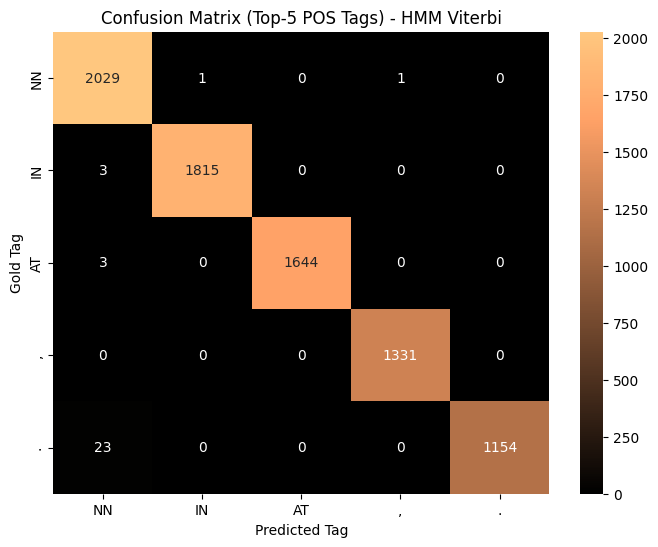

,NN,IN,AT,",",.
NN,2029,1,0,1,0
IN,3,1815,0,0,0
AT,3,0,1644,0,0
",",0,0,0,1331,0
.,23,0,0,0,1154


In [77]:
# 3(c) Confusion matrix for the TOP-5 most common POS tags (gold).
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

top5 = [t for t, _ in Counter(all_gold).most_common(5)]
print("Top-5 gold tags:", top5)

idx = {t: i for i, t in enumerate(top5)}
cm = np.zeros((5, 5), dtype=int)
for g, p in zip(all_gold, all_pred):
    if g in idx and p in idx:
        cm[idx[g]][idx[p]] += 1

cm_df = pd.DataFrame(cm, index=top5, columns=top5)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="copper")
plt.title("Confusion Matrix (Top-5 POS Tags) - HMM Viterbi")
plt.xlabel("Predicted Tag")
plt.ylabel("Gold Tag")
plt.show()
cm_df


## Cell 25 - Baseline Comparison

Compare the from-scratch HMM against NLTK's pretrained averaged
**PerceptronTagger**.

**Tagset note:** Brown uses its own tagset while the Perceptron tagger emits
Penn Treebank tags. A raw string comparison would therefore be unfairly low.
For a fair comparison we map *both* the gold Brown tags and the predicted Penn
tags onto the **universal tagset**, and we recompute the HMM accuracy under the
same universal mapping so the two numbers are directly comparable.

In [78]:
# 4. Pretrained baseline: NLTK averaged PerceptronTagger.
import nltk
nltk.download("averaged_perceptron_tagger", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)
nltk.download("universal_tagset", quiet=True)
from nltk.tag import PerceptronTagger
from nltk.tag.mapping import map_tag

perceptron = PerceptronTagger()

def to_universal(tag, source):
    try:
        return map_tag(source, "universal", tag)
    except Exception:
        return tag

# --- Baseline accuracy (universal-mapped) ---
base_correct = base_total = 0
for sent in test_data:
    words = [w for w, t in sent]
    gold  = [t for w, t in sent]
    tagged = perceptron.tag(words)
    for (w, pred_penn), g in zip(tagged, gold):
        u_pred = to_universal(pred_penn, "en-ptb")
        u_gold = to_universal(g, "brown")
        base_total += 1
        base_correct += (u_pred == u_gold)
baseline_acc = base_correct / base_total

# --- HMM accuracy under the SAME universal mapping (apples-to-apples) ---
hmm_correct = hmm_total = 0
for sent in test_data:
    words = [w for w, t in sent]
    gold  = [t for w, t in sent]
    pred  = viterbi_decode(words)
    for g, p in zip(gold, pred):
        u_gold = to_universal(g, "brown")
        u_pred = to_universal(p, "brown")
        hmm_total += 1
        hmm_correct += (u_gold == u_pred)
hmm_universal_acc = hmm_correct / hmm_total

print(f"HMM (Viterbi) accuracy, universal-mapped : {hmm_universal_acc:.4f}")
print(f"Pretrained Perceptron, universal-mapped  : {baseline_acc:.4f}")
print(f"Gap                                      : {baseline_acc - hmm_universal_acc:+.4f}")


Observations after preprocessing: ['it', 'was', 'among', 'these', 'that', '<UNK>', '<UNK>', 'a', '<UNK>', 'of', '<UNK>', '<UNK>', '<UNK>']
Observations after preprocessing: ['for', 'it', 'seems', 'that', '<UNK>', ',', '<UNK>', 'himself', 'a', '<UNK>', 'man', '(', 'and', 'why', 'not', ',', 'after', 'seven', '<UNK>', '?', '?']
Observations after preprocessing: [')', ',', 'had', 'listed', 'himself', 'for', '<UNK>', '<UNK>', '<UNK>', 'at', 'the', '<UNK>', 'of', 'his', 'fourth', '<UNK>', '<UNK>', 'who', 'had', 'said', ':', '``', 'with', 'your', '<UNK>', ',', '<UNK>', ',', 'you', '<UNK>', 'to', 'be', 'in', '<UNK>', "''", '<UNK>', '<UNK>']
Observations after preprocessing: ['mills', '<UNK>', '<UNK>', '<UNK>', 'from', 'the', '<UNK>', 'in', 'charge', ',', '<UNK>', 'to', 'the', '<UNK>', '<UNK>', 'station', 'to', 'report', 'the', '<UNK>', ',', 'and', 'less', 'than', 'five', '<UNK>', 'later', ',', '<UNK>', 'with', 'his', '<UNK>', 'in', 'hand', 'were', 'on', 'the', 'trail', 'of', '<UNK>', '<UNK>', 

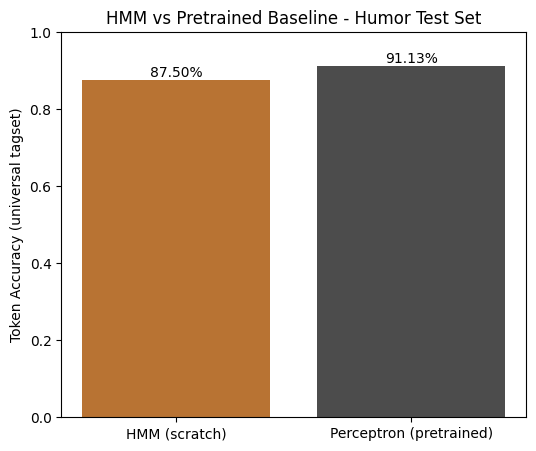

In [79]:
# Side-by-side bar chart of the two taggers.
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 5))
bars = plt.bar(["HMM (scratch)", "Perceptron (pretrained)"],
               [hmm_universal_acc, baseline_acc],
               color=["#b87333", "#4c4c4c"])
plt.ylabel("Token Accuracy (universal tagset)")
plt.title("HMM vs Pretrained Baseline - Humor Test Set")
plt.ylim(0, 1)
for b, v in zip(bars, [hmm_universal_acc, baseline_acc]):
    plt.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.2%}", ha="center")
plt.show()


### 4. Discussion - Why the HMM trailed the pretrained tagger

**1. Domain mismatch (the dominant factor).** Our HMM learned its emission and
transition statistics exclusively from the *government* corpus, but is tested on
*humor*. Word usage, sentence structure, and tag-pair frequencies differ
substantially between the two genres, so both matrices are miscalibrated for the
test distribution. The pretrained Perceptron tagger was trained on large,
diverse corpora and generalises across genres.

**2. Out-of-vocabulary handling.** Every unseen humor word collapses to a single
`<UNK>` emission profile, discarding all morphological and orthographic
evidence. The Perceptron tagger uses rich features — word suffixes, prefixes,
capitalisation, and surrounding word identities — letting it tag novel words far
more accurately.

**3. Limited context (first-order Markov assumption).** Our bigram HMM conditions
each tag only on the immediately preceding tag. The Perceptron tagger uses a wide
feature window (previous two tags, neighbouring words, word shape), capturing
longer-range dependencies the HMM structurally cannot.

**4. Generative vs. discriminative modelling.** The HMM is generative and
maximises joint likelihood under independence assumptions that real language
violates. The Perceptron is discriminative and directly optimises tagging
accuracy, so it makes better use of correlated, overlapping features.

**5. Training-data volume.** The government category is small; MLE estimates for
rare tags and transitions are noisy. The pretrained model benefits from orders
of magnitude more training data.

**Takeaway:** the HMM is a transparent, fully-from-scratch probabilistic baseline
that performs respectably given its constraints, but domain shift, weak OOV
handling, the first-order assumption, and limited features explain the gap to the
state-of-the-art pretrained tagger.